# BCHH instrument-response correction and infraBSU/NRL validation

This standalone notebook separates waveform calibration from figure generation.

It performs four tasks:

1. loads the raw BCHH miniSEED and the StationXML epoch active during the 1 September 2016 event;
2. extracts station/channel coordinates directly from that inventory;
3. produces the primary corrected waveform product using the event StationXML;
4. independently constructs corrected infraBSU + Centaur responses from the Nominal Response Library (NRL) and compares them with the event metadata.

The event StationXML is treated as authoritative for the production correction. The NRL responses are diagnostic checks. No `flovopy.stationmetadata.build` or `flovopy.stationmetadata.infrabsu` functions are imported: corrected standalone versions are included below.


## 1. Imports and configuration

Edit only the paths and time windows in this section before running the notebook.


In [1]:
from __future__ import annotations

import copy
import json
import os
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from obspy import Stream, UTCDateTime, read, read_inventory
from obspy.clients.nrl import NRL
from obspy.core.inventory import Channel, Inventory, Network, Site, Station
from obspy.core.inventory.response import InstrumentSensitivity, Response

plt.rcParams.update({"figure.dpi": 120, "font.size": 9})


In [2]:
# Project paths
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

MINISEED_DIR = Path(
    "/Volumes/haldata/KSC/beforePASSCAL/EVENTS/20160901_SpaceXplosion"
)
STATIONXML_FILE = PROJECT_ROOT / "metadata" / "KSC.xml"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "response_correction"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_CACHE = OUTPUT_DIR / "bchh_raw_event_window.mseed"
CORRECTED_MSEED = OUTPUT_DIR / "bchh_corrected_stationxml.mseed"
CORRECTED_STATIONXML = OUTPUT_DIR / "bchh_event_inventory.xml"
CHANNEL_METADATA_CSV = OUTPUT_DIR / "bchh_channel_metadata.csv"
CORRECTION_SUMMARY_CSV = OUTPUT_DIR / "bchh_correction_summary.csv"
NRL_COMPARISON_CSV = OUTPUT_DIR / "infrabsu_nrl_response_comparison.csv"
PROCESSING_JSON = OUTPUT_DIR / "bchh_response_processing.json"

OVERWRITE_RAW_CACHE = False
OVERWRITE_CORRECTED = True

# Event and processing windows
EXPLOSION_TIME = UTCDateTime("2016-09-01T13:07:12.080")
READ_START = EXPLOSION_TIME - 180.0
READ_END = EXPLOSION_TIME + 1800.0

# A quiet interval used only to remove the digitizer DC offset from pressure data.
PRESSURE_BASELINE_START = EXPLOSION_TIME - 20.0
PRESSURE_BASELINE_END = EXPLOSION_TIME - 2.0

# Seismic deconvolution stabilization.
SEISMIC_PRE_FILT = (0.02, 0.05, 80.0, 100.0)
SEISMIC_WATER_LEVEL_DB = 60.0

# Metadata selection
BCHH_NETWORK = "1R"
BCHH_STATION = "BCHH"
BCHH_LOCATION = "10"

# Waveform files and StationXML use different channel/network/location codes.
WAVEFORM_TO_XML_CHANNEL = {
    "HD1": "DD1",
    "HD2": "DD2",
    "HD3": "DD3",
    "HHE": "DHE",
    "HHN": "DHN",
    "HHZ": "DHZ",
}
XML_TO_WAVEFORM_CHANNEL = {v: k for k, v in WAVEFORM_TO_XML_CHANNEL.items()}
CHANNEL_ORDER = list(WAVEFORM_TO_XML_CHANNEL)


## 2. Load and subset the event inventory

Coordinates, elevations, channel orientations, sample rates, and responses are all taken from the active StationXML epoch. No station coordinates are hardcoded.


In [3]:
def load_event_inventory(
    stationxml_file: Path,
    *,
    network: str,
    station: str,
    location: str,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
) -> Inventory:
    """Load the StationXML and retain only active BCHH channel epochs."""
    if not stationxml_file.exists():
        raise FileNotFoundError(stationxml_file)

    inventory = read_inventory(str(stationxml_file))
    selected = inventory.select(
        network=network,
        station=station,
        location=location,
        time=starttime,
    )

    # Retain only channels that overlap the requested time interval.
    keep = set(WAVEFORM_TO_XML_CHANNEL.values())
    selected = copy.deepcopy(selected)
    for net in selected:
        for sta in net:
            sta.channels = [
                cha for cha in sta.channels
                if cha.code in keep
                and (cha.start_date is None or cha.start_date <= endtime)
                and (cha.end_date is None or cha.end_date >= starttime)
            ]

    if not any(sta.channels for net in selected for sta in net):
        raise ValueError("No active BCHH response channels found in StationXML")

    return selected


def inventory_channels_to_dataframe(inventory: Inventory) -> pd.DataFrame:
    """Flatten channel coordinates and response sensitivities into a table."""
    rows = []
    for net in inventory:
        for sta in net:
            for cha in sta:
                response = cha.response
                sensitivity = getattr(response, "instrument_sensitivity", None)
                rows.append({
                    "seed_id": f"{net.code}.{sta.code}.{cha.location_code}.{cha.code}",
                    "network": net.code,
                    "station": sta.code,
                    "location": cha.location_code,
                    "channel": cha.code,
                    "waveform_channel": XML_TO_WAVEFORM_CHANNEL.get(cha.code),
                    "latitude": float(cha.latitude),
                    "longitude": float(cha.longitude),
                    "elevation_m": float(cha.elevation),
                    "depth_m": float(cha.depth),
                    "azimuth_deg": None if cha.azimuth is None else float(cha.azimuth),
                    "dip_deg": None if cha.dip is None else float(cha.dip),
                    "sample_rate_hz": None if cha.sample_rate is None else float(cha.sample_rate),
                    "sensitivity": None if sensitivity is None else float(sensitivity.value),
                    "sensitivity_frequency_hz": None if sensitivity is None else float(sensitivity.frequency),
                    "input_units": None if sensitivity is None else str(sensitivity.input_units),
                    "output_units": None if sensitivity is None else str(sensitivity.output_units),
                })
    return pd.DataFrame(rows).sort_values("channel").reset_index(drop=True)


inventory_event = load_event_inventory(
    STATIONXML_FILE,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    starttime=READ_START,
    endtime=READ_END,
)

channel_metadata_df = inventory_channels_to_dataframe(inventory_event)
display(channel_metadata_df)

inventory_event.write(str(CORRECTED_STATIONXML), format="STATIONXML", validate=True)
channel_metadata_df.to_csv(CHANNEL_METADATA_CSV, index=False)
print(f"Saved event inventory: {CORRECTED_STATIONXML}")
print(f"Saved channel coordinates: {CHANNEL_METADATA_CSV}")


,seed_id,network,station,location,channel,waveform_channel,latitude,longitude,elevation_m,depth_m,azimuth_deg,dip_deg,sample_rate_hz,sensitivity,sensitivity_frequency_hz,input_units,output_units
0,1R.BCHH.10.DD1,1R,BCHH,10,DD1,HD1,28.574222,-80.572417,0.0,0.0,0.0,0.0,250.0,1.840000e+01,1.0,Pa,count
1,1R.BCHH.10.DD2,1R,BCHH,10,DD2,HD2,28.573881,-80.572296,0.0,0.0,90.0,0.0,250.0,1.840000e+01,1.0,Pa,count
2,1R.BCHH.10.DD3,1R,BCHH,10,DD3,HD3,28.574006,-80.572560,0.0,0.0,0.0,0.0,250.0,1.840000e+01,1.0,Pa,count
3,1R.BCHH.10.DHE,1R,BCHH,10,DHE,HHE,28.574017,-80.572376,0.0,0.0,90.0,0.0,250.0,3.017200e+08,1.0,m/s,count
4,1R.BCHH.10.DHN,1R,BCHH,10,DHN,HHN,28.574017,-80.572376,0.0,0.0,0.0,0.0,250.0,3.017200e+08,1.0,m/s,count
5,1R.BCHH.10.DHZ,1R,BCHH,10,DHZ,HHZ,28.574017,-80.572376,0.0,0.0,0.0,-90.0,250.0,3.017200e+08,1.0,m/s,count


Saved event inventory: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_event_inventory.xml
Saved channel coordinates: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_channel_metadata.csv


## 3. Read and cache the raw BCHH stream


In [4]:
def read_bchh_stream(
    miniseed_dir: Path,
    cache_file: Path,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
    *,
    overwrite_cache: bool = False,
) -> Stream:
    """Read BCHH day files, trim, merge, and optionally cache the raw counts."""
    if cache_file.exists() and not overwrite_cache:
        st = read(str(cache_file))
        st.trim(starttime, endtime, pad=False)
        return st

    patterns = ["*.20160901T000000", "*.mseed", "*.msd", "*.miniseed"]
    files = []
    for pattern in patterns:
        files.extend(miniseed_dir.glob(pattern))
    files = sorted(set(files))

    if not files:
        raise FileNotFoundError(f"No miniSEED files found in {miniseed_dir}")

    st = Stream()
    for filename in files:
        st += read(str(filename))

    st.trim(starttime, endtime, pad=False)
    st.merge(method=1, fill_value="interpolate")
    st.sort(keys=["station", "channel"])
    st.write(str(cache_file), format="MSEED")
    return st


st_raw = read_bchh_stream(
    MINISEED_DIR,
    RAW_CACHE,
    READ_START,
    READ_END,
    overwrite_cache=OVERWRITE_RAW_CACHE,
)

print(st_raw)
for tr in st_raw:
    print(tr.id, tr.stats.starttime, tr.stats.endtime, tr.stats.sampling_rate, tr.stats.npts)


9 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD1 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD2 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD3 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD1 2016-09-01T13:04:12.080000Z 2016-09-01T13:37:12.

## 4. Production correction using the event StationXML

The pressure and seismic channels are treated differently:

- **infraBSU (`HD*`)**: counts are divided by the StationXML overall sensitivity. The response is approximately flat over the analysis band, and this avoids unstable inversion near zero frequency. A pre-event median is then removed to eliminate the digitizer DC offset.
- **Trillium Compact (`HH*`)**: the complete response is removed to velocity using a pre-filter and finite water level.

The original waveform IDs are restored after response lookup.


In [5]:
def remap_trace_to_inventory_id(
    trace,
    *,
    inventory_network: str,
    inventory_station: str,
    inventory_location: str,
):
    """Copy a waveform trace and temporarily assign its StationXML NSLC code."""
    out = trace.copy()
    waveform_channel = out.stats.channel.upper()
    if waveform_channel not in WAVEFORM_TO_XML_CHANNEL:
        raise ValueError(f"No StationXML mapping defined for {trace.id}")

    original_codes = {
        "network": out.stats.network,
        "station": out.stats.station,
        "location": out.stats.location,
        "channel": out.stats.channel,
    }
    out.stats.network = inventory_network
    out.stats.station = inventory_station
    out.stats.location = inventory_location
    out.stats.channel = WAVEFORM_TO_XML_CHANNEL[waveform_channel]
    return out, original_codes


def restore_trace_id(trace, original_codes: dict) -> None:
    for key, value in original_codes.items():
        setattr(trace.stats, key, value)


def median_in_window(trace, starttime: UTCDateTime, endtime: UTCDateTime) -> float:
    window = trace.copy().trim(starttime, endtime, pad=False)
    if window.stats.npts == 0:
        raise ValueError(f"No samples in baseline window for {trace.id}")
    return float(np.nanmedian(np.asarray(window.data, dtype=np.float64)))


def correct_bchh_with_event_inventory(
    stream: Stream,
    inventory: Inventory,
    *,
    inventory_network: str,
    inventory_station: str,
    inventory_location: str,
    pressure_baseline_start: UTCDateTime,
    pressure_baseline_end: UTCDateTime,
    seismic_pre_filt: tuple[float, float, float, float],
    seismic_water_level_db: float,
) -> tuple[Stream, pd.DataFrame]:
    """Return corrected BCHH data and a trace-by-trace processing summary."""
    corrected = Stream()
    rows = []

    for raw_trace in stream:
        xml_trace, original_codes = remap_trace_to_inventory_id(
            raw_trace,
            inventory_network=inventory_network,
            inventory_station=inventory_station,
            inventory_location=inventory_location,
        )
        response = inventory.get_response(xml_trace.id, xml_trace.stats.starttime)
        sensitivity = response.instrument_sensitivity
        waveform_channel = original_codes["channel"].upper()

        if waveform_channel.startswith("HD"):
            if str(sensitivity.input_units).lower() != "pa":
                raise ValueError(f"Expected Pa input units for {xml_trace.id}, got {sensitivity.input_units}")

            out = raw_trace.copy()
            out.data = np.asarray(out.data, dtype=np.float64) / float(sensitivity.value)
            baseline_pa = median_in_window(out, pressure_baseline_start, pressure_baseline_end)
            out.data -= baseline_pa
            units = "Pa"
            method = "overall_sensitivity_plus_pre_event_median"
            pre_filt = None
            water_level = None

        elif waveform_channel.startswith("HH"):
            out = xml_trace.copy()
            out.detrend("demean")
            out.detrend("linear")
            out.taper(max_percentage=0.05, type="cosine")
            out.remove_response(
                inventory=inventory,
                output="VEL",
                pre_filt=seismic_pre_filt,
                water_level=seismic_water_level_db,
                zero_mean=False,
                taper=False,
            )
            restore_trace_id(out, original_codes)
            baseline_pa = np.nan
            units = "m/s"
            method = "full_response_to_velocity"
            pre_filt = seismic_pre_filt
            water_level = seismic_water_level_db
        else:
            raise ValueError(f"Unsupported waveform channel {raw_trace.id}")

        # MiniSEED does not retain arbitrary Stats fields; details are also saved to CSV/JSON.
        out.stats.units = units
        corrected += out
        rows.append({
            "waveform_id": raw_trace.id,
            "inventory_id": xml_trace.id,
            "method": method,
            "units": units,
            "overall_sensitivity": float(sensitivity.value),
            "sensitivity_input_units": str(sensitivity.input_units),
            "sensitivity_output_units": str(sensitivity.output_units),
            "removed_pressure_baseline_pa": baseline_pa,
            "pre_filt": None if pre_filt is None else repr(tuple(pre_filt)),
            "water_level_db": water_level,
        })

    corrected.sort(keys=["station", "channel"])
    return corrected, pd.DataFrame(rows)


st_corrected, correction_summary_df = correct_bchh_with_event_inventory(
    st_raw,
    inventory_event,
    inventory_network=BCHH_NETWORK,
    inventory_station=BCHH_STATION,
    inventory_location=BCHH_LOCATION,
    pressure_baseline_start=PRESSURE_BASELINE_START,
    pressure_baseline_end=PRESSURE_BASELINE_END,
    seismic_pre_filt=SEISMIC_PRE_FILT,
    seismic_water_level_db=SEISMIC_WATER_LEVEL_DB,
)

display(correction_summary_df)


,waveform_id,inventory_id,method,units,overall_sensitivity,sensitivity_input_units,sensitivity_output_units,removed_pressure_baseline_pa,pre_filt,water_level_db
0,FL.BCHH.00.HD1,1R.BCHH.10.DD1,overall_sensitivity_plus_pre_event_median,Pa,1.840000e+01,Pa,count,-19973.858696,NaN,NaN
1,FL.BCHH.10.HD1,1R.BCHH.10.DD1,overall_sensitivity_plus_pre_event_median,Pa,1.840000e+01,Pa,count,-19998.369565,NaN,NaN
2,FL.BCHH.00.HD2,1R.BCHH.10.DD2,overall_sensitivity_plus_pre_event_median,Pa,1.840000e+01,Pa,count,104.402174,NaN,NaN
3,FL.BCHH.10.HD2,1R.BCHH.10.DD2,overall_sensitivity_plus_pre_event_median,Pa,1.840000e+01,Pa,count,104.456522,NaN,NaN
4,FL.BCHH.00.HD3,1R.BCHH.10.DD3,overall_sensitivity_plus_pre_event_median,Pa,1.840000e+01,Pa,count,1261.684783,NaN,NaN
5,FL.BCHH.10.HD3,1R.BCHH.10.DD3,overall_sensitivity_plus_pre_event_median,Pa,1.840000e+01,Pa,count,1261.847826,NaN,NaN
6,FL.BCHH.00.HHE,1R.BCHH.10.DHE,full_response_to_velocity,m/s,3.017200e+08,m/s,count,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0
7,FL.BCHH.00.HHN,1R.BCHH.10.DHN,full_response_to_velocity,m/s,3.017200e+08,m/s,count,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0
8,FL.BCHH.00.HHZ,1R.BCHH.10.DHZ,full_response_to_velocity,m/s,3.017200e+08,m/s,count,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0


## 5. Save corrected waveforms and processing metadata

The corrected miniSEED uses floating-point encoding. Because miniSEED does not preserve arbitrary unit or processing fields, the StationXML, channel-coordinate CSV, correction-summary CSV, and JSON provenance file are written beside it.


In [6]:
if OVERWRITE_CORRECTED or not CORRECTED_MSEED.exists():
    st_corrected.write(str(CORRECTED_MSEED), format="MSEED", encoding="FLOAT64")

correction_summary_df.to_csv(CORRECTION_SUMMARY_CSV, index=False)

processing_metadata = {
    "raw_data_directory": str(MINISEED_DIR),
    "raw_cache": str(RAW_CACHE),
    "source_stationxml": str(STATIONXML_FILE),
    "saved_event_stationxml": str(CORRECTED_STATIONXML),
    "corrected_miniseed": str(CORRECTED_MSEED),
    "read_start": str(READ_START),
    "read_end": str(READ_END),
    "pressure_baseline_start": str(PRESSURE_BASELINE_START),
    "pressure_baseline_end": str(PRESSURE_BASELINE_END),
    "seismic_pre_filt": list(SEISMIC_PRE_FILT),
    "seismic_water_level_db": SEISMIC_WATER_LEVEL_DB,
    "waveform_to_stationxml_channel": WAVEFORM_TO_XML_CHANNEL,
}
PROCESSING_JSON.write_text(json.dumps(processing_metadata, indent=2))

print(f"Corrected waveforms: {CORRECTED_MSEED}")
print(f"Event inventory:      {CORRECTED_STATIONXML}")
print(f"Channel metadata:     {CHANNEL_METADATA_CSV}")
print(f"Correction summary:   {CORRECTION_SUMMARY_CSV}")
print(f"Processing metadata:  {PROCESSING_JSON}")


Corrected waveforms: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_corrected_stationxml.mseed
Event inventory:      /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_event_inventory.xml
Channel metadata:     /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_channel_metadata.csv
Correction summary:   /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_correction_summary.csv
Processing metadata:  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_response_processing.json


## 6. Basic amplitude and waveform checks


In [7]:
def summarize_window(stream: Stream, starttime: UTCDateTime, endtime: UTCDateTime) -> pd.DataFrame:
    rows = []
    for trace in stream:
        window = trace.copy().trim(starttime, endtime, pad=False)
        data = np.asarray(window.data, dtype=np.float64)
        rows.append({
            "id": trace.id,
            "units": trace.stats.get("units", "Pa" if trace.stats.channel.startswith("HD") else "m/s"),
            "minimum": float(np.nanmin(data)),
            "maximum": float(np.nanmax(data)),
            "peak_absolute": float(np.nanmax(np.abs(data))),
            "peak_to_peak": float(np.nanmax(data) - np.nanmin(data)),
            "rms": float(np.sqrt(np.nanmean(data ** 2))),
        })
    return pd.DataFrame(rows)

CHECK_START = EXPLOSION_TIME - 10.0
CHECK_END = EXPLOSION_TIME + 30.0
amplitude_summary_df = summarize_window(st_corrected, CHECK_START, CHECK_END)
display(amplitude_summary_df)


,id,units,minimum,maximum,peak_absolute,peak_to_peak,rms
0,FL.BCHH.00.HD1,Pa,-122.010870,569.891304,569.891304,691.902174,31.198841
1,FL.BCHH.10.HD1,Pa,-97.500000,594.402174,594.402174,691.902174,23.368008
2,FL.BCHH.00.HD2,Pa,-9.565217,58.641304,58.641304,68.206522,1.939664
3,FL.BCHH.10.HD2,Pa,-9.619565,58.586957,58.586957,68.206522,1.941195
4,FL.BCHH.00.HD3,Pa,-142.336957,787.119565,787.119565,929.456522,28.091941
5,FL.BCHH.10.HD3,Pa,-142.500000,786.956522,786.956522,929.456522,28.128270
6,FL.BCHH.00.HHE,m/s,-0.001094,0.001004,0.001094,0.002097,0.000087
7,FL.BCHH.00.HHN,m/s,-0.002207,0.001867,0.002207,0.004074,0.000144
8,FL.BCHH.00.HHZ,m/s,-0.002876,0.002173,0.002876,0.005050,0.000222


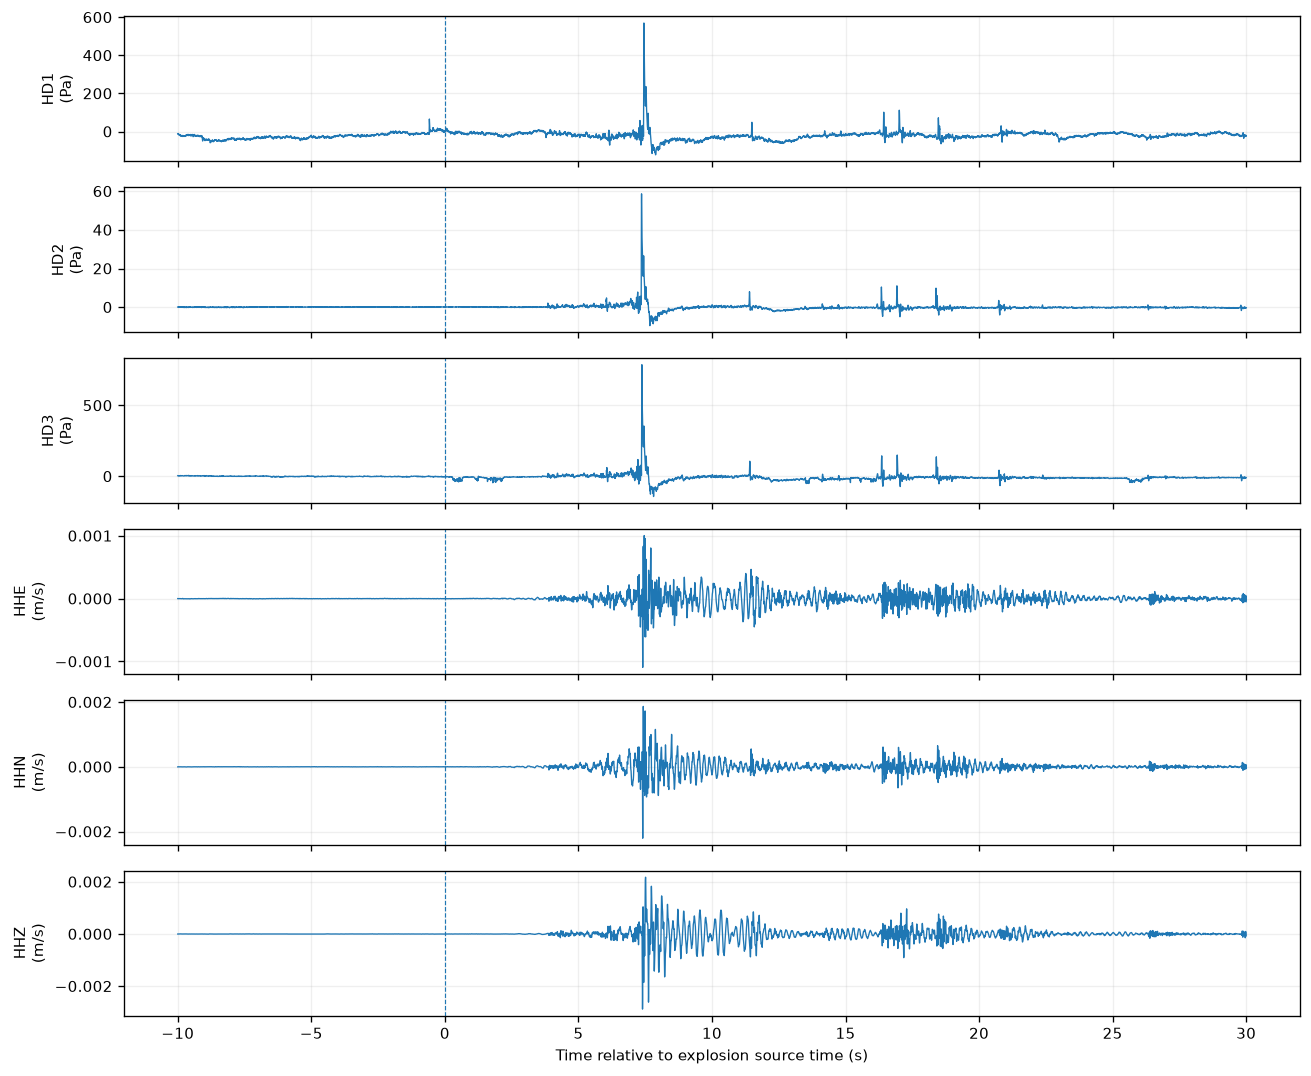

In [8]:
fig, axes = plt.subplots(len(CHANNEL_ORDER), 1, figsize=(11, 9), sharex=True)
for ax, channel in zip(axes, CHANNEL_ORDER):
    matches = st_corrected.select(channel=channel)
    if not matches:
        ax.set_visible(False)
        continue
    trace = matches[0].copy().trim(CHECK_START, CHECK_END)
    time_s = trace.times() + float(trace.stats.starttime - EXPLOSION_TIME)
    ax.plot(time_s, trace.data, linewidth=0.8)
    ax.axvline(0.0, linestyle="--", linewidth=0.7)
    units = "Pa" if channel.startswith("HD") else "m/s"
    ax.set_ylabel(f"{channel}\n({units})")
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("Time relative to explosion source time (s)")
fig.tight_layout()
plt.show()


# Part II — corrected standalone infraBSU/NRL functions

The following functions replace the relevant experimental functionality from `build.py` and `infrabsu.py` inside this notebook.

Important corrections:

- infraBSU input units are explicitly `Pa`;
- the infraBSU sensor sensitivity is `4.6e-5 V/Pa`;
- Centaur 40 Vpp is used for BCHH, yielding `18.4 count/Pa`;
- Centaur 1 Vpp would yield `736 count/Pa`;
- there is no erroneous `18400 count/Pa` fallback;
- each requested channel receives an independent deep copy of the response;
- coordinates and epoch times are explicit arguments.


## 7. General inventory builder (corrected replacement for `build.NRL2inventory`)


In [9]:
def _make_nrl(nrl_path: Optional[Path | str] = None) -> NRL:
    """Open a local NRL when supplied; otherwise use the remote NRL service."""
    if nrl_path is not None and Path(nrl_path).is_dir():
        return NRL(str(nrl_path))
    return NRL("https://ds.iris.edu/NRL/")


def _centaur_keys(vpp: float, sample_rate_hz: float) -> list[str]:
    if float(vpp) == 40.0:
        gain_key = "40 Vpp (1)"
    elif float(vpp) == 1.0:
        gain_key = "1 Vpp (40)"
    else:
        raise ValueError(f"Centaur Vpp must be 1 or 40, got {vpp}")
    return [
        "Nanometrics", "Centaur", gain_key,
        "Off", "Linear phase", f"{int(sample_rate_hz)}",
    ]


def _sensor_keys(sensor: str) -> list[str]:
    name = sensor.strip().lower()
    if name == "infrabsu":
        return ["JeffreyBJohnson", "infraBSU", "0.000046 V/Pa"]
    if name in {"tcp", "trillium compact", "trillium compact 120"}:
        return ["Nanometrics", "Trillium Compact 120 (Vault, Posthole, OBS)", "754 V/m/s"]
    if name.startswith("chap"):
        return ["Chaparral Physics", "25", "Low: 0.4 V/Pa"]
    raise ValueError(f"Unsupported sensor: {sensor}")


def responses_to_inventory(
    *,
    network: str,
    station: str,
    location: str,
    channel_codes: Iterable[str],
    response: Response,
    sample_rate_hz: float,
    latitude: float,
    longitude: float,
    elevation_m: float,
    depth_m: float,
    start_date: UTCDateTime,
    end_date: UTCDateTime,
    site_name: str = "",
    source: str = "standalone NRL builder",
) -> Inventory:
    """Create a one-station Inventory and deep-copy the response per channel."""
    channels = []
    for channel_code in channel_codes:
        channels.append(Channel(
            code=str(channel_code),
            location_code=str(location),
            latitude=float(latitude),
            longitude=float(longitude),
            elevation=float(elevation_m),
            depth=float(depth_m),
            sample_rate=float(sample_rate_hz),
            start_date=start_date,
            end_date=end_date,
            response=copy.deepcopy(response),
        ))

    sta = Station(
        code=str(station),
        latitude=float(latitude),
        longitude=float(longitude),
        elevation=float(elevation_m),
        creation_date=start_date,
        site=Site(name=site_name or station),
        channels=channels,
    )
    net = Network(code=str(network), stations=[sta], start_date=start_date, end_date=end_date)
    return Inventory(networks=[net], source=source)


def NRL2inventory(
    nrl_path,
    net,
    sta,
    loc,
    chans,
    datalogger="Centaur",
    sensor="TCP",
    Vpp=40,
    fsamp=100.0,
    lat=0.0,
    lon=0.0,
    elev=0.0,
    depth=0.0,
    sitename="",
    ondate=UTCDateTime(1970, 1, 1),
    offdate=UTCDateTime(2100, 1, 1),
) -> Inventory:
    """Corrected standalone replacement for `flovopy.stationmetadata.build.NRL2inventory`.

    This implementation deliberately fails loudly if the NRL lookup fails; it does
    not silently construct a physically ambiguous fallback response.
    """
    if datalogger.lower() != "centaur":
        raise ValueError("This focused notebook supports the Nanometrics Centaur only")
    channel_codes = [chans] if isinstance(chans, str) else list(chans)

    nrl = _make_nrl(nrl_path)
    response = nrl.get_response(
        sensor_keys=_sensor_keys(sensor),
        datalogger_keys=_centaur_keys(Vpp, fsamp),
    )

    return responses_to_inventory(
        network=net,
        station=sta,
        location=loc,
        channel_codes=channel_codes,
        response=response,
        sample_rate_hz=fsamp,
        latitude=lat,
        longitude=lon,
        elevation_m=elev,
        depth_m=depth,
        start_date=ondate,
        end_date=offdate,
        site_name=sitename,
        source=f"NRL: {sensor} + {datalogger} {Vpp:g} Vpp",
    )


## 8. infraBSU-specific builder (corrected replacement for `infrabsu.py`)

The direct NRL combination is preferred. A sensor-template function is retained for explicit inspection or offline reuse, but it does not depend on FLOVOpy.


In [10]:
DEFAULT_INFRABSU_SENSOR_URL = (
    "https://service.iris.edu/irisws/nrl/1/combine"
    "?instconfig=sensor_JeffreyBJohnson_infraBSU_LP21_SG0.000046_STairPressure"
    "&format=stationxml"
)


def get_infrabsu_sensor_template(
    local_filename: Path | str = "infraBSU_sensor.xml",
    url: str = DEFAULT_INFRABSU_SENSOR_URL,
    timeout_s: float = 60.0,
    overwrite: bool = False,
) -> Path:
    """Download/cache the sensor-only infraBSU StationXML without FLOVOpy dependencies."""
    path = Path(local_filename).expanduser().resolve()
    if path.exists() and not overwrite:
        return path

    import requests
    response = requests.get(url, timeout=timeout_s)
    response.raise_for_status()
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(response.content)

    # Verify that the downloaded file is readable StationXML.
    read_inventory(str(path))
    return path


def get_infrabsu_centaur(
    *,
    fsamp: float,
    vpp: float,
    network: str,
    station: str,
    location: str,
    channels: Iterable[str] | str,
    latitude: float,
    longitude: float,
    elevation: float,
    depth: float,
    start_date: UTCDateTime,
    end_date: UTCDateTime,
    nrl_path: Optional[Path | str] = None,
) -> Inventory:
    """Build an infraBSU + Centaur inventory directly from the NRL.

    For the BCHH 2016 deployment use `vpp=40`, which should produce an overall
    sensitivity of 18.4 count/Pa at 1 Hz.
    """
    channel_codes = [channels] if isinstance(channels, str) else list(channels)
    return NRL2inventory(
        nrl_path=nrl_path,
        net=network,
        sta=station,
        loc=location,
        chans=channel_codes,
        datalogger="Centaur",
        sensor="infrabsu",
        Vpp=vpp,
        fsamp=fsamp,
        lat=latitude,
        lon=longitude,
        elev=elevation,
        depth=depth,
        sitename=station,
        ondate=start_date,
        offdate=end_date,
    )


## 9. Build 40 Vpp and 1 Vpp NRL responses using inventory coordinates

This cell gets the coordinates from `inventory_event`, not from hardcoded constants.


In [11]:
def station_coordinates_from_inventory(
    inventory: Inventory,
    *,
    network: str,
    station: str,
    location: str,
    channel: str,
    time: UTCDateTime,
) -> dict:
    selected = inventory.select(
        network=network,
        station=station,
        location=location,
        channel=channel,
        time=time,
    )
    channels = [cha for net in selected for sta in net for cha in sta]
    if len(channels) != 1:
        raise ValueError(f"Expected one channel for coordinate lookup, found {len(channels)}")
    cha = channels[0]
    return {
        "latitude": float(cha.latitude),
        "longitude": float(cha.longitude),
        "elevation": float(cha.elevation),
        "depth": float(cha.depth),
        "sample_rate": float(cha.sample_rate),
    }


bchh_coordinates = station_coordinates_from_inventory(
    inventory_event,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    channel="DD1",
    time=EXPLOSION_TIME,
)
print(bchh_coordinates)

inv_infrabsu_nrl_40vpp = get_infrabsu_centaur(
    fsamp=bchh_coordinates["sample_rate"],
    vpp=40,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    channels=["DD1", "DD2", "DD3"],
    latitude=bchh_coordinates["latitude"],
    longitude=bchh_coordinates["longitude"],
    elevation=bchh_coordinates["elevation"],
    depth=bchh_coordinates["depth"],
    start_date=READ_START,
    end_date=READ_END,
)

inv_infrabsu_nrl_1vpp = get_infrabsu_centaur(
    fsamp=bchh_coordinates["sample_rate"],
    vpp=1,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    channels=["DD1", "DD2", "DD3"],
    latitude=bchh_coordinates["latitude"],
    longitude=bchh_coordinates["longitude"],
    elevation=bchh_coordinates["elevation"],
    depth=bchh_coordinates["depth"],
    start_date=READ_START,
    end_date=READ_END,
)


{'latitude': 28.57422161, 'longitude': -80.57241686, 'elevation': 0.0, 'depth': 0.0, 'sample_rate': 250.0}


/var/folders/sz/wyydztsx6q7gbrq8b1pl4fl00000gn/T/ipykernel_68420/809774998.py:5: ObsPyDeprecationWarning: 
        DEPRECATED

        Direct access to online NRL is deprecated as it will stop working when
        the original NRLv1 gets taken offline (Spring 2023), please consider
        working locally with a downloaded full copy of the old NRLv1 or new
        NRLv2 following instructions on the
        `NRL landing page <https://ds.iris.edu/ds/nrl/>`_.
        
  return NRL("https://ds.iris.edu/NRL/")


KeyError: 'JeffreyBJohnson'

## 10. Stage-by-stage response inspection


In [ ]:
def response_stage_table(inventory: Inventory, seed_id: str, time: UTCDateTime) -> pd.DataFrame:
    response = inventory.get_response(seed_id, time)
    sensitivity = response.instrument_sensitivity
    rows = [{
        "stage": 0,
        "type": "Overall sensitivity",
        "gain": float(sensitivity.value),
        "gain_frequency_hz": float(sensitivity.frequency),
        "input_units": str(sensitivity.input_units),
        "output_units": str(sensitivity.output_units),
    }]
    for stage in response.response_stages:
        rows.append({
            "stage": int(stage.stage_sequence_number),
            "type": type(stage).__name__,
            "gain": None if stage.stage_gain is None else float(stage.stage_gain),
            "gain_frequency_hz": None if stage.stage_gain_frequency is None else float(stage.stage_gain_frequency),
            "input_units": str(stage.input_units),
            "output_units": str(stage.output_units),
        })
    return pd.DataFrame(rows)


for label, inventory in [
    ("Event StationXML", inventory_event),
    ("NRL 40 Vpp", inv_infrabsu_nrl_40vpp),
    ("NRL 1 Vpp", inv_infrabsu_nrl_1vpp),
]:
    print(f"\n{label}")
    display(response_stage_table(inventory, "1R.BCHH.10.DD1", EXPLOSION_TIME))


## 11. Frequency-response comparison

This compares amplitude and phase rather than only the nominal sensitivity at 1 Hz.


In [ ]:
def evaluate_response_at_frequencies(
    inventory: Inventory,
    seed_id: str,
    time: UTCDateTime,
    target_frequencies_hz: Iterable[float],
    sample_rate_hz: float,
    nfft: int = 2 ** 18,
) -> pd.DataFrame:
    response = inventory.get_response(seed_id, time)
    complex_response, frequencies = response.get_evalresp_response(
        t_samp=1.0 / sample_rate_hz,
        nfft=nfft,
        output="DEF",
    )
    rows = []
    for target in target_frequencies_hz:
        index = int(np.argmin(np.abs(frequencies - float(target))))
        value = complex_response[index]
        rows.append({
            "frequency_hz": float(frequencies[index]),
            "amplitude_count_per_pa": float(np.abs(value)),
            "phase_deg": float(np.degrees(np.angle(value))),
        })
    return pd.DataFrame(rows)


TEST_FREQUENCIES_HZ = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 80, 100]
comparison_tables = []
for label, inventory in [
    ("event_stationxml", inventory_event),
    ("nrl_40vpp", inv_infrabsu_nrl_40vpp),
    ("nrl_1vpp", inv_infrabsu_nrl_1vpp),
]:
    table = evaluate_response_at_frequencies(
        inventory,
        "1R.BCHH.10.DD1",
        EXPLOSION_TIME,
        TEST_FREQUENCIES_HZ,
        bchh_coordinates["sample_rate"],
    )
    table.insert(0, "source", label)
    comparison_tables.append(table)

nrl_response_comparison_df = pd.concat(comparison_tables, ignore_index=True)
nrl_response_comparison_df.to_csv(NRL_COMPARISON_CSV, index=False)
display(nrl_response_comparison_df)


In [ ]:
amplitude_pivot = nrl_response_comparison_df.pivot(
    index="frequency_hz",
    columns="source",
    values="amplitude_count_per_pa",
)
amplitude_pivot["nrl_40vpp_to_event"] = (
    amplitude_pivot["nrl_40vpp"] / amplitude_pivot["event_stationxml"]
)
amplitude_pivot["nrl_1vpp_to_event"] = (
    amplitude_pivot["nrl_1vpp"] / amplitude_pivot["event_stationxml"]
)
display(amplitude_pivot)


## 12. Data-domain comparison: sensitivity-only pressure

This test should give identical waveforms for the event StationXML and NRL 40 Vpp inventories when their overall sensitivities agree. The 1 Vpp result should be smaller by a factor of 40.


In [ ]:
def pressure_from_inventory_sensitivity(
    raw_trace,
    inventory: Inventory,
    inventory_seed_id: str,
    baseline_start: UTCDateTime,
    baseline_end: UTCDateTime,
):
    response = inventory.get_response(inventory_seed_id, raw_trace.stats.starttime)
    sensitivity = response.instrument_sensitivity
    if str(sensitivity.input_units).lower() != "pa":
        raise ValueError(f"Expected Pa, got {sensitivity.input_units}")

    out = raw_trace.copy()
    out.data = np.asarray(out.data, dtype=np.float64) / float(sensitivity.value)
    out.data -= median_in_window(out, baseline_start, baseline_end)
    out.stats.units = "Pa"
    return out


data_domain_rows = []
for waveform_channel, xml_channel in [("HD1", "DD1"), ("HD2", "DD2"), ("HD3", "DD3")]:
    raw_trace = st_raw.select(channel=waveform_channel)[0]
    for label, inventory in [
        ("event_stationxml", inventory_event),
        ("nrl_40vpp", inv_infrabsu_nrl_40vpp),
        ("nrl_1vpp", inv_infrabsu_nrl_1vpp),
    ]:
        corrected = pressure_from_inventory_sensitivity(
            raw_trace,
            inventory,
            f"{BCHH_NETWORK}.{BCHH_STATION}.{BCHH_LOCATION}.{xml_channel}",
            PRESSURE_BASELINE_START,
            PRESSURE_BASELINE_END,
        ).trim(CHECK_START, CHECK_END)
        data = np.asarray(corrected.data, dtype=np.float64)
        data_domain_rows.append({
            "channel": waveform_channel,
            "response_source": label,
            "minimum_pa": float(np.nanmin(data)),
            "maximum_pa": float(np.nanmax(data)),
            "peak_absolute_pa": float(np.nanmax(np.abs(data))),
            "peak_to_peak_pa": float(np.nanmax(data) - np.nanmin(data)),
        })

data_domain_comparison_df = pd.DataFrame(data_domain_rows)
display(data_domain_comparison_df)


## 13. Optional full-deconvolution comparison for infraBSU

This is deliberately diagnostic, not the production method. It demonstrates how strongly the result depends on low-frequency stabilization. Do not run with both `pre_filt=None` and `water_level=None`.


In [ ]:
def full_infrasound_deconvolution(
    raw_trace,
    inventory: Inventory,
    inventory_seed_id: str,
    *,
    pre_filt=(0.05, 0.1, 80.0, 100.0),
    water_level_db=60.0,
):
    out = raw_trace.copy()
    parts = inventory_seed_id.split(".")
    out.stats.network, out.stats.station, out.stats.location, out.stats.channel = parts
    out.detrend("demean")
    out.detrend("linear")
    out.taper(max_percentage=0.05, type="cosine")
    out.remove_response(
        inventory=inventory,
        output="DEF",
        pre_filt=pre_filt,
        water_level=water_level_db,
        zero_mean=False,
        taper=False,
    )
    out.stats.units = "Pa"
    return out


# Example for HD1. Change RUN_FULL_INFRASOUND_DECONVOLUTION to True to execute.
RUN_FULL_INFRASOUND_DECONVOLUTION = False
if RUN_FULL_INFRASOUND_DECONVOLUTION:
    raw_hd1 = st_raw.select(channel="HD1")[0]
    full_event = full_infrasound_deconvolution(
        raw_hd1, inventory_event, "1R.BCHH.10.DD1"
    ).trim(CHECK_START, CHECK_END)
    full_nrl = full_infrasound_deconvolution(
        raw_hd1, inv_infrabsu_nrl_40vpp, "1R.BCHH.10.DD1"
    ).trim(CHECK_START, CHECK_END)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(full_event.times(), full_event.data, label="Event StationXML", linewidth=0.8)
    ax.plot(full_nrl.times(), full_nrl.data, label="NRL 40 Vpp", linewidth=0.8, alpha=0.75)
    ax.set_xlabel("Time from comparison-window start (s)")
    ax.set_ylabel("Pressure (Pa)")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()


## 14. Expected interpretation

A successful run should show:

- event StationXML infraBSU sensitivity: approximately **18.4 count/Pa**;
- NRL 40 Vpp sensitivity: approximately **18.4 count/Pa**;
- NRL 1 Vpp sensitivity: approximately **736 count/Pa**;
- NRL 40 Vpp / event response amplitude ratio near 1 through the useful passband;
- sensitivity-corrected event and NRL 40 Vpp waveforms numerically identical apart from floating-point roundoff;
- the 1 Vpp pressure waveform smaller by a factor of approximately 40.

The output bundle in `outputs/response_correction/` can then be consumed by the figure-generation notebook without repeating calibration experiments.
